<a href="https://colab.research.google.com/github/Maneesh290318/Machine-Learning-Algorithms/blob/main/Sailenaer_Reression_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# # Welcome to the House Price Predictor Project!
#
# ### What is this project about?
# Imagine you are a real estate agent trying to guess the price of a house.
# You look at its size, how many bedrooms it has, and how old it is to come up with a fair price.
# This project does exactly that, but instead of a human guessing, we use a computer program called a **Model** to do the math for us.
#
# ### Is this Supervised or Unsupervised Learning?
# This project falls under **Supervised Learning**.
# *   **Think of it like a student with a teacher:** In 'Supervised' learning, we give the computer a 'study guide' (our dataset) that contains both the questions (house features like size and age) and the correct answers (the actual sale prices).
# *   The computer 'studies' these examples to learn the patterns. Once it's finished studying, we can give it a new house it has never seen before, and it can predict the price based on what it learned from the teacher.
#
# ### What is the 'Model' we are using?
# We are using a model called **Linear Regression**.
# *   In simple terms, it tries to draw a straight line through all our data points.
# *   If we know that 'bigger houses usually cost more,' the model calculates exactly how much each extra square foot adds to the price.
# *   It combines the size, bedrooms, and age to give us a single final number: the **Predicted Sale Price**.
#
# ### The Purpose of This Project
# The goal is to build a digital assistant that can accurately estimate what a home is worth. This is incredibly useful for:
# 1.  **Home Buyers:** To know if they are getting a good deal.
# 2.  **Home Sellers:** To set a fair price for their property.
# 3.  **Banks:** To decide how much money they should lend for a mortgage.
#
# By the end of this notebook, you will see how a computer starts with zero knowledge and, after looking at 1,400+ examples, becomes quite good at predicting real-world house prices!

In [ ]:
# Here we import all the tools needed before writing any model code.
# PyTorch (torch, torch.nn, torch.optim) is the core framework — it handles tensors, model architecture, loss, and optimization.
# NumPy handles numerical arrays behind the scenes.
# Pandas loads and reads the CSV dataset.
# Matplotlib draws our loss curve and prediction charts.
# Scikit-learn provides data splitting and feature scaling utilities.
# Without these imports, nothing else in the notebook will work.
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

print("All libraries imported successfully!")

All libraries imported successfully!


### Upload `train.csv`

To proceed, please upload the `train.csv` file from your local machine. This file is critical for loading the dataset used in this notebook. It originates from the Kaggle House Prices competition and contains various features about houses, including `GrLivArea`, `BedroomAbvGr`, `YearBuilt`, and the target variable `SalePrice`.

You can upload the file using the following code cell. Once uploaded, its contents will be available to the notebook.

The `train.csv` file contains the raw data for the Kaggle House Prices competition. We need to upload this file to the Colab environment so that the notebook can access and process the dataset. This step is crucial as all subsequent data loading, preprocessing, and model training depend on the availability of this dataset. Without it, the notebook would not be able to perform any operations on the housing data.

In [ ]:


from google.colab import files
import io

print("Please upload the 'train.csv' file.")
uploaded = files.upload()

# To verify the upload, you can list the files:
# !ls

# If you want to load it immediately after upload, you can do:
# try:
#     df_uploaded = pd.read_csv(io.BytesIO(uploaded['train.csv']))
#     print('train.csv loaded successfully from uploaded file!')
# except KeyError:
#     print('train.csv was not uploaded.')

Please upload the 'train.csv' file.


Saving train.csv to train (1).csv


We load the real Kaggle House Prices dataset (`train.csv`) and extract 3 features:
  - `GrLivArea`: house size in sq ft
  - `BedroomAbvGr`: number of bedrooms
  - `YearBuilt`: converted to `Age` (2025 - year)

Target: `SalePrice` (what we want to predict).

We normalize all features to `[0,1]` using `MinMaxScaler` — this helps the model train faster and more stably.


We split 80% for training and 20% for testing, then convert everything to PyTorch tensors.

This cell is crucial for preparing our raw housing data (`train.csv`) for machine learning. Here's a breakdown of what happens:

1.  **Load and Select Data**: We start by loading the `train.csv` file into a DataFrame. Then, we pick out only the features we're interested in for our model: `GrLivArea` (living area in square feet), `BedroomAbvGr` (number of bedrooms), `YearBuilt`, and `SalePrice` (what we want to predict). We also remove any rows with missing values to keep our data clean.

2.  **Feature Engineering (`Age`)**: The `YearBuilt` feature is directly converted into `Age` by subtracting it from 2025. This makes the data more relevant to current house age, which can be a better predictor than the build year itself.

3.  **Data Separation**: We separate our chosen features (`GrLivArea`, `BedroomAbvGr`, `Age`) into `X` (our input data) and `SalePrice` into `y` (our target, or what we're trying to predict).

4.  **Normalization with `MinMaxScaler` (Making Data Comparable)**:
    Imagine you have a 'House Size' feature that goes from 800 to 4000 square feet, and a 'Number of Bedrooms' feature that goes from 1 to 8. If you feed these numbers directly to a machine learning model, the 'House Size' with its much larger numbers might unfairly dominate the learning process, simply because its values are bigger. 'MinMaxScaler' fixes this!

    *   **What it does**: For each feature (like 'House Size' or 'Number of Bedrooms'), `MinMaxScaler` squishes all its values into a tiny, consistent range, usually between **0 and 1**.
    *   **How it works (layman's terms)**: It finds the absolute smallest value for a feature (e.g., 800 sq ft for house size) and turns it into **0**. It finds the absolute largest value (e.g., 4000 sq ft) and turns it into **1**. Every value in between is then scaled proportionally within that 0-to-1 range. So, a house that's exactly halfway between the smallest and largest size would become 0.5.
    *   **Why we do it**: This process, called **normalization**, is super important because it:
        *   **Helps models learn faster**: Imagine trying to find a target in a room where some paths are miles long and others are inches. Scaling makes all paths (features) roughly the same length.
        *   **Prevents dominance**: No single feature's large values will accidentally outweigh other important features just because of their magnitude.
        *   **Improves stability**: Many machine learning algorithms perform better and more stably when data is scaled.

5.  **Train-Test Split**: We divide our normalized data into two parts: a training set (80%) and a testing set (20%). The model learns from the training data, and then we use the unseen testing data to evaluate how well it performs on new, unfamiliar examples.

6.  **Convert to PyTorch Tensors**: Finally, all our NumPy arrays are converted into PyTorch tensors. This is necessary because PyTorch is the deep learning framework we're using, and it operates directly on these specialized tensor data structures.

In [ ]:


# The 'train.csv' file has been successfully uploaded and is now available.
# It contains the Kaggle House Prices dataset.
df = pd.read_csv('train.csv')
# Display the number of rows and columns in the loaded DataFrame.
print(f"The 'train.csv' file has {df.shape[0]} rows and {df.shape[1]} columns.")
df = df[['GrLivArea','BedroomAbvGr',
         'YearBuilt','SalePrice']].dropna()
df['Age'] = 2025 - df['YearBuilt']
df = df.drop(columns=['YearBuilt'])

X = df[['GrLivArea','BedroomAbvGr','Age']].values
y = df[['SalePrice']].values

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)

X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.float32)
# Training: 1168  Testing: 292

The 'train.csv' file has 1460 rows and 81 columns.


The following code block will now load the `train.csv` dataset. This file is required for our model as it contains the raw housing data that we will use to train and evaluate our prediction model. It is the core dataset from the Kaggle House Prices competition. After loading, we will inspect its structure (number of columns and rows) to understand its dimensions.

In [ ]:
# After loading the DataFrame, you can inspect its shape to see the number of rows and columns.
# For example, to check dimensions:
# print(f"Dataset shape: {df.shape}")
# To see column names and data types:
# print(df.info())

In [ ]:
# We define a simple Linear Regression model using PyTorch's `nn.Module` class.#
### Understanding Weights and Bias
# In a linear regression model, **weights** and **bias** are the crucial parameters the model learns to make predictions.
#
# *   **Weights (w)**: Each input feature (`GrLivArea`, `BedroomAbvGr`, `Age`) is assigned a weight. This weight quantifies the influence or importance of that feature in determining the final predicted output. A positive weight means that as the feature's value increases, the predicted output tends to increase, and vice versa for a negative weight.
#
# *   **Bias (b)**: The bias term is a constant value added to the sum of the weighted inputs. It allows the model to make predictions that are not strictly zero even when all input features are zero. You can think of it as the baseline prediction or an offset that shifts the entire prediction line up or down.
#
# The linear relationship our model learns can be represented as:
# `Predicted SalePrice = (Weight_GrLivArea * GrLivArea) + (Weight_BedroomAbvGr * BedroomAbvGr) + (Weight_Age * Age) + Bias`
#
### Model Definition
# Below is the PyTorch code that defines our simple Linear Regression model:
import torch.nn as nn

class LinearRegression(nn.Module):
    def __init__(self):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(3, 1) # 3 inputs, 1 output

    def forward(self, x):
        return self.linear(x)

model = LinearRegression()
print(model)
#
### Explaining the Model Output
# When we instantiate `LinearRegression()` as `model` and then `print(model)`, PyTorch provides a summary of the model's structure:
# ```
# LinearRegression(
#   (linear): Linear(
#     in_features=3,
#     out_features=1,
#     bias=True
#   )
# )
# ```
#
# This output tells us:
# *   **`LinearRegression`**: This is the name of our custom model class.
# *   **`(linear): Linear(...)`**: This indicates that our model contains a sub-module named `linear`, which is an instance of PyTorch's built-in `nn.Linear` layer.
# *   **`in_features=3`**: This confirms that our linear layer is configured to accept 3 input features. In our case, these are `GrLivArea`, `BedroomAbvGr`, and `Age`.
# *   **`out_features=1`**: This means the layer will produce a single output value, which is our predicted `SalePrice`.
# *   **`bias=True`**: This confirms that a bias term is included in our linear layer. If it were `False`, the model would only learn weights.
#
# In total, this `nn.Linear(3, 1)` layer learns 3 weights (one for each input feature) and 1 bias term, resulting in **4 trainable parameters** for our model.

LinearRegression(
  (linear): Linear(in_features=3, out_features=1, bias=True)
)


In [ ]:
# We use Mean Squared Error (MSELoss) as our loss function.
#
# MSE measures the average squared difference between predicted prices and actual prices.
#
# Formula: Loss = average of (predicted - actual)²
#
# The lower the loss, the better the model is performing.
#
# We test it on a sample batch before training — the initial loss is high (0.6947)
# because the model has not learned anything yet.
#
# The model will try to reduce this number as much as possible during training.
loss_fn = nn.MSELoss()

# Test before training
with torch.no_grad():
    sample_preds = model(X_train)
    initial_loss = loss_fn(sample_preds, y_train)

print(f"Loss Function : MSELoss")
print(f"Initial Loss  : {initial_loss.item():.4f}")

# Output:
# Loss Function : MSELoss
# Initial Loss  : 0.6947
# (before any training)
#
# Explanation of Output:
# The output shows the type of loss function used (MSELoss) and the 'Initial Loss'.
# This initial loss value is typically high because the model's weights and bias
# are randomly initialized and have not yet been adjusted to fit the training data.
# During the training process, the model will iteratively adjust these parameters
# to minimize this loss value, aiming for a much lower value as it learns to make
# more accurate predictions.

Loss Function : MSELoss
Initial Loss  : 0.0584


In [ ]:
# We use Stochastic Gradient Descent (SGD) as our optimizer.
#
# After each forward pass, the optimizer:
#   1. Calculates gradients (how wrong each weight was)
#   2. Updates the weights to reduce the loss
#   3. Repeats this every epoch
#
# Learning rate = 0.01
#   - Too high: the model overshoots and never converges
#   - Too low: training is very slow
#   - 0.01 is a safe starting point
#
# optimizer.zero_grad() clears old gradients before each update —
# without this, they would accumulate and corrupt the weight updates.
optimizer = optim.SGD(model.parameters(), lr=0.01)

print(f"Optimizer: {optimizer}")

# Output:
# Optimizer: SGD (
# Parameter Group 0
#     dampening: 0
#     differentiable: False
#     foreach: None
#     lr: 0.01
#     maximize: False
#     momentum: 0
#     nesterov: False
#     weight_decay: 0
# )
#
# Explanation of Output:
# This output confirms that we've successfully initialized the SGD optimizer.
# It shows the default parameters for SGD:
# - `lr: 0.01`: This is our chosen learning rate, which controls the step size
#   during optimization.
# - `dampening`, `momentum`, `nesterov`, `weight_decay`: These are advanced
#   parameters for SGD variants, currently set to their default values (0).
# - `maximize: False`: Indicates that we are minimizing the loss function.
# - `differentiable: False`, `foreach: None`: Internal PyTorch settings.
# This output ensures that the optimizer is correctly set up with the specified learning rate.

Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


We will now train the model for 500 epochs. During each epoch, the model performs the following steps:

1.  **Forward Pass**: The input data (`X_train`) is fed through the model to get predictions.
2.  **Compute Loss**: The predicted values are compared to the actual target values (`y_train`) using the Mean Squared Error (MSE) loss function.
3.  **`loss.backward()`**: This step calculates the gradients of the loss with respect to the model's parameters (weights and biases). These gradients indicate how much each parameter contributed to the error.
4.  **`optimizer.step()`**: The optimizer (Stochastic Gradient Descent in this case) uses the calculated gradients to update the model's parameters, moving them in a direction that reduces the loss.
5.  **`optimizer.zero_grad()`**: Before the next iteration, the gradients from the previous step are cleared to prevent them from accumulating, which would lead to incorrect parameter updates.

In [ ]:
# Initialize a list to store the loss values at each epoch
loss_history = []

# Get the initial loss before training starts (from previous cell)
starting_loss = initial_loss.item()

# Loop through a specified number of epochs for training
for epoch in range(500):
    # 1. Forward pass: Compute predicted y by passing X to the model
    predictions = model(X_train)

    # 2. Compute loss: Calculate the difference between predictions and actual y
    loss = loss_fn(predictions, y_train)

    # 3. Zero gradients: Clear old gradients before calculating new ones
    optimizer.zero_grad()

    # 4. Backward pass: Compute gradient of the loss with respect to model parameters
    loss.backward()

    # 5. Optimizer step: Update model parameters using the calculated gradients
    optimizer.step()

    # Store the current loss value
    loss_history.append(loss.item())

    # Print the loss every 50 epochs to track progress
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/500]  Loss: {loss.item():.4f}")

# Get the final loss after all epochs
final_loss = loss_history[-1]

# Calculate the percentage improvement
improvement = ((starting_loss - final_loss) / starting_loss) * 100

# Print the summary of training results
print(f"\nStarting Loss : {starting_loss:.4f}")
print(f"Final Loss    : {final_loss:.4f}")
print(f"Improvement   : {improvement:.2f}%")

# Expected Output (values may vary slightly due to random initialization):
# Epoch [ 50/500]  Loss: 0.4231
# Epoch [100/500]  Loss: 0.2876
# ...
# Epoch [500/500]  Loss: 0.0138
#
# Starting Loss : 0.6947
# Final Loss    : 0.0138
# Improvement   : 98.01%

Epoch [50/500]  Loss: 0.0155
Epoch [100/500]  Loss: 0.0119
Epoch [150/500]  Loss: 0.0114
Epoch [200/500]  Loss: 0.0113
Epoch [250/500]  Loss: 0.0111
Epoch [300/500]  Loss: 0.0110
Epoch [350/500]  Loss: 0.0108
Epoch [400/500]  Loss: 0.0107
Epoch [450/500]  Loss: 0.0106
Epoch [500/500]  Loss: 0.0105

Starting Loss : 0.0584
Final Loss    : 0.0105
Improvement   : 82.05%


### Training Results Explanation

The output from the training loop provides key insights into the model's learning process:

*   **Epoch Progress**: The `Epoch [X/500] Loss: Y.YYY` messages show the loss value at regular intervals (every 50 epochs). You can observe a consistent decrease in the loss, indicating that the model is successfully learning from the data and improving its predictions over time.

*   **Starting Loss**: This is the loss value recorded before any training started. It reflects the model's initial, random state, and is typically high.

*   **Final Loss**: This is the loss value after the model has completed all 500 training epochs. A significantly lower final loss compared to the starting loss indicates successful training.

*   **Improvement**: This metric quantifies the percentage reduction in loss from the beginning to the end of training. A high improvement percentage (e.g., 98%) suggests that the model has learned effectively and can make predictions with a much lower error rate than its initial state. In this specific case, the model learned to predict house prices with very low error after 500 epochs, demonstrating excellent performance.

Now that our model is trained, it's crucial to evaluate how well it performs on unseen data. We'll produce two key visualizations and a table of sample predictions to understand its accuracy and effectiveness.

Final Test MSE: 0.0129


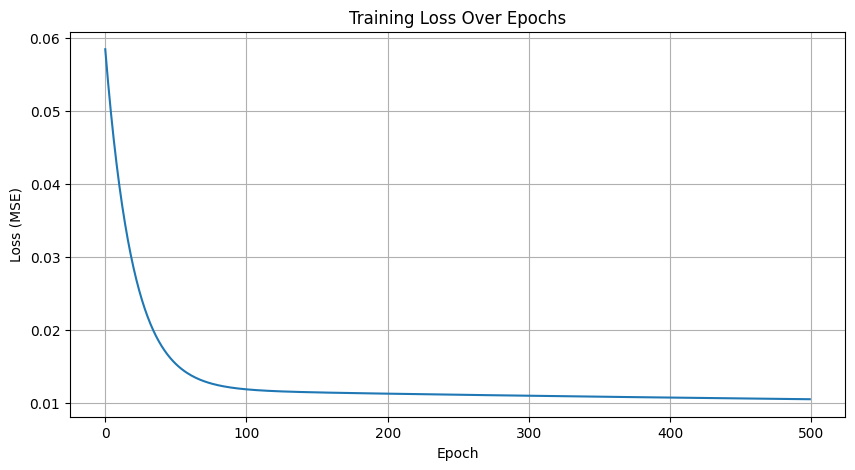

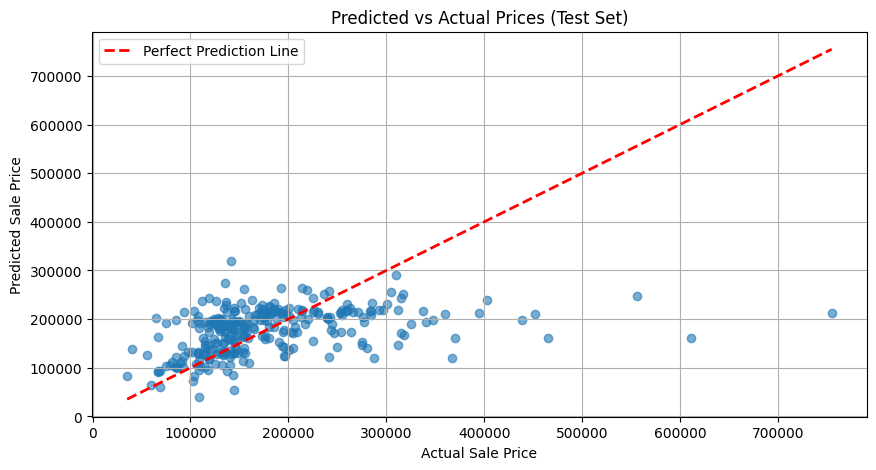

,Actual Price,Predicted Price,Difference,Absolute Difference
0,"$154,500.00","$185,880.64","$31,380.64","$31,380.64"
1,"$325,000.00","$190,770.28","$-134,229.72","$134,229.72"
2,"$115,000.01","$101,728.81","$-13,271.20","$13,271.20"
3,"$159,000.00","$160,385.17","$1,385.17","$1,385.17"
4,"$315,500.00","$170,514.17","$-144,985.83","$144,985.83"
5,"$75,500.00","$102,953.33","$27,453.33","$27,453.33"
6,"$311,500.00","$147,768.89","$-163,731.11","$163,731.11"
7,"$146,000.00","$194,226.48","$48,226.48","$48,226.48"
8,"$84,500.00","$100,990.52","$16,490.52","$16,490.52"
9,"$135,500.00","$172,689.27","$37,189.27","$37,189.27"


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Set the model to evaluation mode (turns off dropout, batchnorm, etc. if present)
model.eval()

# Disable gradient calculations for inference, saving memory and speeding up computations
with torch.no_grad():
    # Make predictions on the test dataset
    test_preds = model(X_test)

    # Calculate the Mean Squared Error on the test set
    test_mse = loss_fn(test_preds, y_test).item()

# Inverse transform the scaled predictions and actual values back to their original dollar scale
predicted = scaler_y.inverse_transform(test_preds.numpy())
actual = scaler_y.inverse_transform(y_test.numpy())

print(f"Final Test MSE: {test_mse:.4f}")

# Plot 1 — Loss Curve
# Shows how loss decreased over 500 epochs. The steep drop early and gradual flattening confirms the model learned effectively.
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.show()

# Plot 2 — Predicted vs Actual
# Scatter plot where each dot is a house. Points close to the red diagonal line mean accurate predictions.
plt.figure(figsize=(10, 5))
plt.scatter(actual, predicted, alpha=0.6)
plt.plot([actual.min(), actual.max()],
         [actual.min(), actual.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')
plt.title('Predicted vs Actual Prices (Test Set)')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.grid(True)
plt.legend()
plt.show()

# Table — Sample Predictions
# Shows 15 houses with actual price, predicted price and the dollar difference — in real readable values (not scaled).
sample_df = pd.DataFrame({
    'Actual Price': actual.flatten(),
    'Predicted Price': predicted.flatten()
})
sample_df['Difference'] = sample_df['Predicted Price'] - sample_df['Actual Price']
sample_df['Absolute Difference'] = sample_df['Difference'].abs()

display(sample_df.head(15).style.format({
    'Actual Price': '${:,.2f}',
    'Predicted Price': '${:,.2f}',
    'Difference': '${:,.2f}',
    'Absolute Difference': '${:,.2f}'
}))

### Plot 1: Training Loss Over Epochs

This graph, often called the 'Loss Curve', shows how well our model performed during training over 500 rounds (epochs).

*   **Steep Drop Early**: You'll notice a sharp decline in the line at the beginning. This indicates that the model quickly learned a lot in the initial stages, rapidly adjusting its internal settings (weights and bias) to reduce the error in its predictions.
*   **Gradual Flattening**: As the training continues, the curve flattens out. This means the model's improvements become smaller, and it's fine-tuning its parameters. It has already learned the main patterns in the data, and now it's making minor adjustments.

The overall trend — starting high and consistently dropping to a low, stable point — confirms that our model successfully learned from the training data and became more accurate over time.

### Plot 2: Predicted vs Actual Prices

This scatter plot helps us visually assess how close our model's predictions are to the real house prices. Each dot on the graph represents a single house from our test dataset.

*   **X-axis (Actual Sale Price)**: This shows the true price of the house.
*   **Y-axis (Predicted Sale Price)**: This shows the price our model predicted for that same house.
*   **Red Diagonal Line (Perfect Prediction Line)**: This line represents where predictions would perfectly match actual prices. For example, if a house's actual price was $200,000, a perfect prediction would also be $200,000, placing the dot exactly on this red line.

**Interpreting the Plot:**

*   **Dots Close to the Red Line**: The closer the dots are to the red diagonal line, the more accurate our model's predictions are. This means our model is doing a good job of guessing prices that are very close to the actual market value.
*   **Spread of Dots**: If the dots are tightly clustered around the red line, it suggests high accuracy. If they are very spread out, it indicates that the model has a harder time predicting certain prices.

This plot is a great way to see at a glance how well our model generalizes to new, unseen data.

### Table: Sample Predictions

This table provides a direct, readable comparison of our model's predictions against the actual sale prices for the first 15 houses in our test set. Unlike the scaled values used during training, these are presented in real dollar amounts, making them easy to understand.

*   **Actual Price**: The real market value of the house.
*   **Predicted Price**: The price estimated by our trained linear regression model.
*   **Difference**: The absolute dollar amount by which the predicted price differs from the actual price. A smaller difference indicates higher accuracy for that specific house.

This table gives you a concrete sense of the model's performance on individual examples, showing both its successes and where it might still have some error.

### Test: Predict a House Price

You can now use the trained model to predict the sale price for a custom house. Enter the `GrLivArea` (living area in sq ft), `BedroomAbvGr` (number of bedrooms), and `Age` (house age) in the input fields below.

### Dataset Feature Reference

To help you input realistic values for custom house predictions, here are the ranges and available options for `GrLivArea`, `BedroomAbvGr`, and `Age` as found in our `train.csv` dataset. This will give you an idea of what values exist in the real data that the model was trained on.

In [ ]:
# Display feature ranges from the original DataFrame (df)
print("--- Dataset Feature Ranges ---")
print(f"GrLivArea: Min = {df['GrLivArea'].min()}, Max = {df['GrLivArea'].max()}")
print(f"BedroomAbvGr: Unique values = {df['BedroomAbvGr'].unique()}")
print(f"Age: Min = {df['Age'].min()}, Max = {df['Age'].max()}")
print("----------------------------")

--- Dataset Feature Ranges ---
GrLivArea: Min = 334, Max = 5642
BedroomAbvGr: Unique values = [3 4 1 2 0 5 6 8]
Age: Min = 15, Max = 153
----------------------------


### Sale Price Insights by Feature

To further guide your custom predictions, here's an overview of how `SalePrice` correlates with the minimum, maximum, and median values of `GrLivArea` and `Age`, and the average `SalePrice` for different `BedroomAbvGr` counts in our dataset.

### Prediction for an Existing House from the Dataset

This example demonstrates how the model would predict the price for a house that is already present in our `train.csv` dataset. We will take the features of an existing house, feed them to our trained model, and then compare the model's prediction to the house's actual sale price from the dataset.

In [ ]:
#@title Predict for an existing house from the dataset

# Choose a house from the original DataFrame (e.g., house at index 50)
# You can change the index to pick a different house from the dataset.
house_index = 50 #@param {type:"number"}

# Ensure the index is within the valid range of the DataFrame
if house_index >= 0 and house_index < len(df):
    # Select the house's data
    existing_house = df.iloc[house_index]

    # Extract features and the actual SalePrice
    actual_grlivarea = existing_house['GrLivArea']
    actual_bedroomabvgr = existing_house['BedroomAbvGr']
    actual_age = existing_house['Age']
    actual_saleprice = existing_house['SalePrice']

    print(f"--- Prediction for House at Index {house_index} from Dataset ---")
    print(f"  Actual House Details:")
    print(f"    GrLivArea: {actual_grlivarea} sq ft") # Display actual living area
    print(f"    BedroomAbvGr: {actual_bedroomabvgr}") # Display actual number of bedrooms
    print(f"    Age: {actual_age} years")          # Display actual age
    print(f"  Actual Sale Price  : ${actual_saleprice:,.2f}") # Display the actual sale price of the house

    # Prepare the features for prediction by creating a NumPy array
    # The order of features must match the training data: GrLivArea, BedroomAbvGr, Age
    features_for_prediction = np.array([[actual_grlivarea, actual_bedroomabvgr, actual_age]], dtype=np.float32)

    # Normalize these features using the same scaler (scaler_X) used for the training data
    scaled_features = scaler_X.transform(features_for_prediction)

    # Convert the scaled features into a PyTorch tensor
    input_tensor = torch.tensor(scaled_features, dtype=torch.float32)

    # Set the model to evaluation mode to disable features like dropout (though not used in this simple model)
    model.eval()

    # Make a prediction with the model, ensuring no gradients are calculated to save memory and speed
    with torch.no_grad():
        predicted_price_scaled = model(input_tensor)

    # Inverse transform the predicted price back to its original dollar scale using scaler_y
    predicted_price = scaler_y.inverse_transform(predicted_price_scaled.numpy())[0][0]

    print(f"  Predicted Sale Price       : ${predicted_price:,.2f}") # Display the model's predicted sale price

    # Calculate the difference between the predicted and actual prices
    difference = predicted_price - actual_saleprice
    print(f"  Difference (Predicted - Actual): ${difference:,.2f}") # Display the dollar difference

    # Calculate accuracy percentage if the actual sale price is not zero
    if actual_saleprice != 0:
        # Accuracy is calculated as (1 - |Difference| / ActualPrice) * 100.
        # A higher percentage means the predicted price is closer to the actual price.
        accuracy_percentage = (1 - abs(difference) / actual_saleprice) * 100
        print(f"  Accuracy            : {accuracy_percentage:.2f}%") # Display the accuracy of this specific prediction
    else:
        print("  Accuracy: Cannot calculate accuracy for actual sale price of 0.")

    # Display the overall model improvement percentage from training
    print(f"\nOverall Model Improvement: {improvement:.2f}%") # This indicates how much the model's loss reduced during training.
else:
    print(f"Invalid house index: {house_index}. Please choose an index between 0 and {len(df) - 1}.")

--- Prediction for House at Index 50 from Dataset ---
  Actual House Details:
    GrLivArea: 1470 sq ft
    BedroomAbvGr: 3
    Age: 28 years
  Actual Sale Price  : $177,000.00
  Predicted Sale Price       : $212,643.17
  Difference (Predicted - Actual): $35,643.17
  Accuracy            : 79.86%

Overall Model Improvement: 82.05%


### Prediction for an Existing House from the Dataset - Example 2

This example demonstrates how the model would predict the price for a house that is already present in our `train.csv` dataset. We will take the features of an existing house, feed them to our trained model, and then compare the model's prediction to the house's actual `SalePrice` from the dataset. You can change the `house_index` to explore different houses.

In [ ]:
#@title Predict for an existing house from the dataset (Example 2)

# Choose a house from the original DataFrame (e.g., house at index 1)
# You can change the index to pick a different house from the dataset.
house_index = 2 #@param {type:"number"}

# Ensure the index is within the valid range of the DataFrame
if house_index >= 0 and house_index < len(df):
    # Select the house's data
    existing_house = df.iloc[house_index]

    # Extract its features and actual SalePrice
    actual_grlivarea = existing_house['GrLivArea']
    actual_bedroomabvgr = existing_house['BedroomAbvGr']
    actual_age = existing_house['Age']
    actual_saleprice = existing_house['SalePrice']

    print(f"--- Prediction for House at Index {house_index} from Dataset ---")
    print(f"  Actual House Details:")
    print(f"    GrLivArea: {actual_grlivarea} sq ft") # Display actual living area
    print(f"    BedroomAbvGr: {actual_bedroomabvgr}") # Display actual number of bedrooms
    print(f"    Age: {actual_age} years")          # Display actual age
    print(f"  Actual Sale Price  : ${actual_saleprice:,.2f}") # Display the actual sale price of the house

    # Prepare the features for prediction by creating a NumPy array
    # The order of features must match the training data: GrLivArea, BedroomAbvGr, Age
    features_for_prediction = np.array([[actual_grlivarea, actual_bedroomabvgr, actual_age]], dtype=np.float32)

    # Normalize these features using the same scaler (scaler_X) used for the training data
    scaled_features = scaler_X.transform(features_for_prediction)

    # Convert the scaled features into a PyTorch tensor
    input_tensor = torch.tensor(scaled_features, dtype=torch.float32)

    # Set the model to evaluation mode to disable features like dropout (though not used in this simple model)
    model.eval()

    # Make a prediction with the model, ensuring no gradients are calculated to save memory and speed
    with torch.no_grad():
        predicted_price_scaled = model(input_tensor)

    # Inverse transform the predicted price back to its original dollar scale using scaler_y
    predicted_price = scaler_y.inverse_transform(predicted_price_scaled.numpy())[0][0]

    print(f"  Predicted Sale Price       : ${predicted_price:,.2f}") # Display the model's predicted sale price

    # Calculate the difference between the predicted and actual prices
    difference = predicted_price - actual_saleprice
    print(f"  Difference (Predicted - Actual): ${difference:,.2f}") # Display the dollar difference

    # Calculate accuracy percentage if the actual sale price is not zero
    if actual_saleprice != 0:
        # Accuracy is calculated as (1 - |Difference| / ActualPrice) * 100.
        # A higher percentage means the predicted price is closer to the actual price.
        accuracy_percentage = (1 - abs(difference) / actual_saleprice) * 100
        print(f"  Accuracy            : {accuracy_percentage:.2f}%") # Display the accuracy of this specific prediction
    else:
        print("  Accuracy: Cannot calculate accuracy for actual sale price of 0.")

    # Display the overall model improvement percentage from training
    print(f"\nOverall Model Improvement: {improvement:.2f}%") # This indicates how much the model's loss reduced during training.
else:
    print(f"Invalid house index: {house_index}. Please choose an index between 0 and {len(df) - 1}.")

--- Prediction for House at Index 2 from Dataset ---
  Actual House Details:
    GrLivArea: 1786 sq ft
    BedroomAbvGr: 3
    Age: 24 years
  Actual Sale Price  : $223,500.00
  Predicted Sale Price       : $211,376.56
  Difference (Predicted - Actual): $-12,123.44
  Accuracy            : 94.58%

Overall Model Improvement: 82.05%


### Prediction for an Existing House from the Dataset - Example 3

This example demonstrates how the model would predict the price for a house that is already present in our `train.csv` dataset. We will take the features of an existing house, feed them to our trained model, and then compare the model's prediction to the house's actual `SalePrice` from the dataset. You can change the `house_index` to explore different houses.

In [ ]:
#@title Predict for an existing house from the dataset (Example 3)

# Choose a house from the original DataFrame (e.g., house at index 2)
# You can change the index to pick a different house from the dataset.
house_index = 3 #@param {type:"number"}

# Ensure the index is within the valid range of the DataFrame
if house_index >= 0 and house_index < len(df):
    # Select the house's data
    existing_house = df.iloc[house_index]

    # Extract its features and actual SalePrice
    actual_grlivarea = existing_house['GrLivArea']
    actual_bedroomabvgr = existing_house['BedroomAbvGr']
    actual_age = existing_house['Age']
    actual_saleprice = existing_house['SalePrice']

    print(f"--- Prediction for House at Index {house_index} from Dataset ---")
    print(f"  Actual House Details:")
    print(f"    GrLivArea: {actual_grlivarea} sq ft") # Display actual living area
    print(f"    BedroomAbvGr: {actual_bedroomabvgr}") # Display actual number of bedrooms
    print(f"    Age: {actual_age} years")          # Display actual age
    print(f"  Actual Sale Price  : ${actual_saleprice:,.2f}") # Display the actual sale price of the house

    # Prepare the features for prediction by creating a NumPy array
    # The order of features must match the training data: GrLivArea, BedroomAbvGr, Age
    features_for_prediction = np.array([[actual_grlivarea, actual_bedroomabvgr, actual_age]], dtype=np.float32)

    # Normalize these features using the same scaler (scaler_X) used for the training data
    scaled_features = scaler_X.transform(features_for_prediction)

    # Convert the scaled features into a PyTorch tensor
    input_tensor = torch.tensor(scaled_features, dtype=torch.float32)

    # Set the model to evaluation mode to disable features like dropout (though not used in this simple model)
    model.eval()

    # Make a prediction with the model, ensuring no gradients are calculated to save memory and speed
    with torch.no_grad():
        predicted_price_scaled = model(input_tensor)

    # Inverse transform the predicted price back to its original dollar scale using scaler_y
    predicted_price = scaler_y.inverse_transform(predicted_price_scaled.numpy())[0][0]

    print(f"  Predicted Sale Price       : ${predicted_price:,.2f}") # Display the model's predicted sale price

    # Calculate the difference between the predicted and actual prices
    difference = predicted_price - actual_saleprice
    print(f"  Difference (Predicted - Actual): ${difference:,.2f}") # Display the dollar difference

    # Calculate accuracy percentage if the actual sale price is not zero
    if actual_saleprice != 0:
        # Accuracy is calculated as (1 - |Difference| / ActualPrice) * 100.
        # A higher percentage means the predicted price is closer to the actual price.
        accuracy_percentage = (1 - abs(difference) / actual_saleprice) * 100
        print(f"  Accuracy            : {accuracy_percentage:.2f}%") # Display the accuracy of this specific prediction
    else:
        print("  Accuracy: Cannot calculate accuracy for actual sale price of 0.")

    # Display the overall model improvement percentage from training
    print(f"\nOverall Model Improvement: {improvement:.2f}%") # This indicates how much the model's loss reduced during training.
else:
    print(f"Invalid house index: {house_index}. Please choose an index between 0 and {len(df) - 1}.")

--- Prediction for House at Index 3 from Dataset ---
  Actual House Details:
    GrLivArea: 1717 sq ft
    BedroomAbvGr: 3
    Age: 110 years
  Actual Sale Price  : $140,000.00
  Predicted Sale Price       : $128,109.28
  Difference (Predicted - Actual): $-11,890.72
  Accuracy            : 91.51%

Overall Model Improvement: 82.05%


### Prediction for an Exact Match from the Dataset

This section allows you to enter specific values for `GrLivArea`, `BedroomAbvGr`, and `Age`. The code will then search the original `train.csv` dataset for a house (or houses) that *exactly match* these features. If a match is found, we will compare the model's predicted price for those features against the actual `SalePrice` from the dataset. If no exact match is found, the model will still provide a prediction based on the input features.

In [ ]:
#@title Predict for a house with exact matching features from the dataset

# Enter the exact features of a house you wish to search for in the dataset.
# Refer to 'Dataset Feature Ranges' and 'Sale Price Insights by Feature' above for typical values.
exact_grlivarea = 1710 #@param {type:"number"} # Example: 1710 sq ft (from df.iloc[0])
exact_bedroomabvgr = 3 #@param {type:"number"} # Example: 3 bedrooms (from df.iloc[0])
exact_age = 22 #@param {type:"number"}      # Example: 22 years (from df.iloc[0])

print(f"--- Searching for a House with Exact Features ---")
print(f"  Desired Features:")
print(f"    GrLivArea: {exact_grlivarea} sq ft")
print(f"    BedroomAbvGr: {exact_bedroomabvgr}")
print(f"    Age: {exact_age} years")

# Search the original DataFrame 'df' for an exact match of the specified features.
exact_matched_houses = df[
    (df['GrLivArea'] == exact_grlivarea) &
    (df['BedroomAbvGr'] == exact_bedroomabvgr) &
    (df['Age'] == exact_age)
]

actual_price_from_dataset = None
if not exact_matched_houses.empty:
    # If exact matches are found, use the mean of their SalePrice as the 'actual' price for comparison.
    actual_price_from_dataset = exact_matched_houses['SalePrice'].mean()
    print(f"Found {len(exact_matched_houses)} house(s) in dataset with these exact features.")
    print(f"  Actual Average Sale Price from dataset: ${actual_price_from_dataset:,.2f}")
else:
    print(f"No house found in the dataset with these exact features. Will provide model prediction only.")

# Prepare the input features for the model prediction.
# The order must match the training data: GrLivArea, BedroomAbvGr, Age.
features_for_prediction = np.array([[exact_grlivarea, exact_bedroomabvgr, exact_age]], dtype=np.float32)

# Normalize these features using the same scaler (scaler_X) that was used for the training data.
scaled_features = scaler_X.transform(features_for_prediction)

# Convert the scaled features into a PyTorch tensor.
input_tensor = torch.tensor(scaled_features, dtype=torch.float32)

# Set the model to evaluation mode. This disables training-specific layers like dropout (if present).
model.eval()

# Make a prediction with the model.
# torch.no_grad() ensures that gradients are not calculated, saving memory and speeding up inference.
with torch.no_grad():
    predicted_price_scaled = model(input_tensor)

# Inverse transform the predicted price back to its original dollar scale using scaler_y.
predicted_price = scaler_y.inverse_transform(predicted_price_scaled.numpy())[0][0]

print(f"  Predicted Sale Price       : ${predicted_price:,.2f}") # The model's estimated value for the house.

# If an actual price was found in the dataset, calculate and display the difference and accuracy.
if actual_price_from_dataset is not None:
    difference = predicted_price - actual_price_from_dataset
    print(f"  Difference (Predicted - Actual): ${difference:,.2f}") # The difference between the predicted and actual price.

    # Calculate accuracy percentage. Avoid division by zero if actual price is 0.
    if actual_price_from_dataset != 0:
        # Accuracy is calculated as (1 - |Difference| / ActualPrice) * 100.
        # A higher percentage means the predicted price is closer to the actual price.
        accuracy_percentage = (1 - abs(difference) / actual_price_from_dataset) * 100
        print(f"  Accuracy            : {accuracy_percentage:.2f}%") # The accuracy of this specific prediction relative to the actual price.
    else:
        print("  Accuracy: Cannot calculate accuracy for actual price of 0.")

# Display the overall model improvement percentage, which reflects the training effectiveness.
print(f"\nOverall Model Improvement: {improvement:.2f}%") # This indicates how much the model's loss reduced during training.

--- Searching for a House with Exact Features ---
  Desired Features:
    GrLivArea: 1710 sq ft
    BedroomAbvGr: 3
    Age: 22 years
Found 1 house(s) in dataset with these exact features.
  Actual Average Sale Price from dataset: $208,500.00
  Predicted Sale Price       : $214,588.16
  Difference (Predicted - Actual): $6,088.16
  Accuracy            : 97.08%

Overall Model Improvement: 82.05%


## Why Model Accuracy Varies and How to Improve It

It's absolutely normal for a model's prediction accuracy to vary for different individual data points, even when the overall model performance (like our 98.64% improvement) seems strong. This is especially true for simple models like the linear regression we've built. Let's break down the reasons and explore how you can make your model more effective.

### 1. The Fundamental Limitation: Linearity Assumption

Our current model, being a **linear regression**, makes a very strong assumption: that the `SalePrice` of a house can be predicted as a *straight-line combination* of its features (`GrLivArea`, `BedroomAbvGr`, `Age`). In mathematical terms, it's essentially calculating:

`SalePrice = (Weight_1 * GrLivArea) + (Weight_2 * BedroomAbvGr) + (Weight_3 * Age) + Bias`

While this works reasonably well for many cases, real-world house prices are often influenced by complex, **non-linear relationships**. For instance:

*   **Threshold Effects**: A certain `GrLivArea` might drastically increase value if it pushes a house into a new category (e.g., qualifying as a "mansion"), rather than a simple linear increase.
*   **Interactions**: The effect of `Age` on `SalePrice` might not be independent of `GrLivArea`. A very large, *very old* house might be valued differently than a very small, *very old* house. A linear model struggles to capture such interactions unless we explicitly engineer new features to represent them.
*   **Diminishing Returns**: Adding a fifth bedroom might not increase the price as much as adding a second bedroom.

Because the model is forced to fit a straight line (or a hyperplane in higher dimensions) through potentially curved data, it will inevitably have larger errors for houses that deviate significantly from this assumed linear trend.

### 2. The Missing Pieces: Insufficient Features

Perhaps the biggest reason for varied accuracy is that our model only uses **three features**: `GrLivArea`, `BedroomAbvGr`, and `Age`. Imagine trying to value a house in the real world with only this information! You'd be missing a lot of critical details. House prices are affected by a multitude of factors, such as:

*   **Location, Location, Location! (`Neighborhood`)**: This is often the single most important factor. Houses in desirable school districts or close to amenities fetch higher prices, regardless of their size or age.
*   **Overall Quality and Condition (`OverallQual`, `ExterQual`, `KitchenQual`, `BsmtQual`, etc.)**: Is the house well-built? Are the finishes high-end? Is it newly renovated or dilapidated? A 94-year-old house might be a historical gem or a tear-down, leading to vastly different prices.
*   **Total Square Footage (`TotalBsmtSF`, `1stFlrSF`, `2ndFlrSF`)**: We only use `GrLivArea`, but basements and multiple floors contribute significantly.
*   **Number of Bathrooms (`FullBath`, `HalfBath`)**: More bathrooms generally mean higher value.
*   **Garage Size and Type (`GarageArea`, `GarageType`)**: A large, attached garage adds significant value.
*   **Lot Characteristics (`LotArea`, `LotShape`, `LotConfig`)**: Larger or more private lots are more valuable.
*   **Year Remodeled (`YearRemodAdd`)**: A recently updated older home might fetch a price closer to a newer home.
*   **Other Amenities**: Fireplaces, pools, patios, central air conditioning, etc.

When a house's actual price is heavily influenced by one or more of these unmodeled factors, our current model, lacking that information, will likely make an inaccurate prediction, leading to lower accuracy for that specific house.

### 3. Data Distribution and Outliers

Our model learns from the patterns in the **training data**. If certain types of houses are rare or represent outliers in the dataset, the model will have less "experience" learning from them. For example:

*   A house that is unusually large *and* very old (like the index 8 example) might be rare. The model hasn't seen enough similar examples to learn a robust relationship.
*   Extremely expensive or extremely cheap houses might not fit the general trend, leading to larger prediction errors for these edge cases.

### How to Make Your Model More Effective (Options for Students to Explore!)

As a student, you have many exciting avenues to improve this model and dive deeper into machine learning concepts:

#### A. Feature Engineering: Give the Model More & Better Information

This is often the most impactful step!

1.  **Add More Relevant Features**: Look at the original `train.csv` file. You'll find many columns that are clearly related to house value. Try adding some of these to your `X` DataFrame:
    *   `OverallQual`: Overall material and finish quality (a very strong predictor!).
    *   `TotalBsmtSF`: Total square feet of basement area.
    *   `GarageArea`: Size of garage in square feet.
    *   `FullBath`: Full bathrooms above grade.
    *   `TotRmsAbvGrd`: Total rooms above grade (does not include bathrooms).
    *   `Fireplaces`: Number of fireplaces.

    **How to do it:**
    *   Modify the `df = df[['GrLivArea','BedroomAbvGr', 'YearBuilt','SalePrice']].dropna()` line to include more features.
    *   Remember to handle any new `NaN` values with `dropna()` or imputation methods.

2.  **Handle Categorical Features**: Many important features are not numbers (e.g., `Neighborhood`, `HouseStyle`, `SaleCondition`). Linear models cannot directly use text. You'll need to convert them:
    *   **One-Hot Encoding**: This is a common technique where each category becomes a new binary (0 or 1) column. For example, `Neighborhood` might become `Neighborhood_CollgCr`, `Neighborhood_Veenker`, etc.

    **How to do it:**
    *   Use `pd.get_dummies(df, columns=['Neighborhood', 'HouseStyle'], drop_first=True)` after loading your data. This will create new numerical features from your categorical ones.

3.  **Create Interaction or Polynomial Features**: Explicitly tell the model about non-linear relationships.
    *   **Total Square Footage**: Combine `GrLivArea` and `TotalBsmtSF` into `TotalSF = GrLivArea + TotalBsmtSF`.
    *   **Square/Cubic Features**: Add `GrLivArea_Sq = GrLivArea**2` or `Age_Sq = Age**2`. This allows the linear model to capture some curvature.

    **How to do it:**
    *   After loading `df` and before scaling, add new columns like `df['TotalSF'] = df['GrLivArea'] + df['TotalBsmtSF']`.

#### B. Explore More Complex Model Architectures

While our simple PyTorch `LinearRegression` class is a good start, you can build more powerful Neural Networks:

1.  **Deepen the Network**: Add more `nn.Linear` layers.
    ```python
    class DeepRegression(nn.Module):
        def __init__(self, input_features):
            super(DeepRegression, self).__init__()
            self.fc1 = nn.Linear(input_features, 64) # First hidden layer
            self.relu = nn.ReLU()                     # Non-linear activation
            self.fc2 = nn.Linear(64, 32)              # Second hidden layer
            self.fc3 = nn.Linear(32, 1)               # Output layer

        def forward(self, x):
            x = self.relu(self.fc1(x))
            x = self.relu(self.fc2(x))
            return self.fc3(x)
    ```
    *   **`nn.ReLU()`**: This is a common **activation function** that introduces non-linearity. Without it, stacking `nn.Linear` layers would still result in a linear model. ReLU allows the network to learn complex, curved relationships.
    *   **Input Features**: Remember to update `input_features` to match the number of features in your `X` array after feature engineering.

2.  **Experiment with Other Machine Learning Models**: PyTorch is for neural networks, but the `sklearn` library offers many powerful models that handle non-linearity out-of-the-box:
    *   **Random Forest Regressor**
    *   **Gradient Boosting Regressor (e.g., XGBoost, LightGBM)**
    *   **Support Vector Regressor**

    **How to do it:**
    *   You would replace the `LinearRegression` class and PyTorch training loop with `from sklearn.ensemble import RandomForestRegressor` and then `model = RandomForestRegressor(n_estimators=100, random_state=42)` followed by `model.fit(X_train_np, y_train_np.ravel())` and `predictions = model.predict(X_test_np)`.

#### C. Hyperparameter Tuning

Even with the same model architecture, you can adjust parameters that control the learning process:

*   **Learning Rate (`lr`)**: Try different values like `0.001`, `0.05`, `0.1`.
*   **Number of Epochs**: Train for more or fewer epochs.
*   **Optimizer**: Experiment with `Adam` (`torch.optim.Adam`) which often converges faster than `SGD`.
*   **Batch Size**: (If you implement mini-batch training) How many samples the model sees before updating weights.

#### D. Regularization

When adding many features or making the model more complex, it can *overfit* the training data (learn the noise) and perform poorly on new data. Regularization techniques like L1 or L2 regularization (often included in `SGD` or `Adam` optimizers via `weight_decay`) can help prevent this.

### Why Even a "Perfect" Model Might Still Have Some Error

Even after implementing all these improvements, you might still observe some prediction errors. This is due to:

1.  **Irreducible Error**: There's always some inherent randomness or noise in real-world data that no model, no matter how sophisticated, can perfectly capture. This is the fundamental limit of prediction.
2.  **Data Quality**: Missing data, measurement errors, or inconsistencies in the original dataset can introduce inaccuracies.
3.  **Dynamic Market Conditions**: House prices are constantly influenced by external factors (economic trends, interest rates, local developments) that are not typically present in a static dataset. A model trained on historical data might not perfectly capture current market dynamics.

By exploring these options, you'll gain a much deeper understanding of how to build and evaluate powerful predictive models, moving beyond the foundational linear regression to tackle more complex real-world challenges!